In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [2]:
bLattice = np.zeros((11, 11, 11, 361, 3))

bLattice[:,:,:,:,0] = np.arange(-5, 6)[:, np.newaxis, np.newaxis, np.newaxis] * np.pi * 2 / 3.9050 * 1e4
bLattice[:,:,:,:,1] = np.arange(-5, 6)[np.newaxis, :, np.newaxis, np.newaxis] * np.pi * 2 / 3.9050 * 1e4
bLattice[:,:,:,:,2] = np.arange(-5, 6)[np.newaxis, np.newaxis, :, np.newaxis] * np.pi * 2 / 3.9050 * 1e4

tilt_angle = -np.deg2rad(11.5)
tilt_mat = np.array([[np.cos(tilt_angle), 0, -np.sin(tilt_angle)],
                     [0, 1, 0],
                     [np.sin(tilt_angle), 0, np.cos(tilt_angle)],])

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            for idx in range(361):
                angle = np.deg2rad(idx)
                rot_mat = np.array([
                    [1, 0, 0,],
                    [0, np.cos(angle), -np.sin(angle)],
                    [0, np.sin(angle), np.cos(angle)],])
                
                bLattice[xIdx, yIdx, zIdx, idx, :] = np.dot(tilt_mat, np.dot(rot_mat, bLattice[xIdx, yIdx, zIdx, idx]))

In [4]:
#kLen = util.kev_to_wavevec_length(9.8)
#angle = np.deg2rad(11.639) * 2
#kvec = np.array([0, -np.sin(angle), np.cos(angle)]) * kLen

kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(2 * 11.639 - 0.1)
angle2 = np.deg2rad(3.575 * 2)

kvec = np.array([ - np.sin(angle2) * np.sin(angle),
                  - np.cos(angle2) * np.sin(angle),
                 np.cos(angle),
                ]) * kLen

tg_angle = np.deg2rad(2 * 0.1567 - 7e-3)
kvec_tg = np.copy(kvec)
kvec_tg[0] += 2 * np.sin(tg_angle) * kLen

In [5]:
kout = kvec_tg[np.newaxis, np.newaxis, np.newaxis, np.newaxis] + bLattice
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

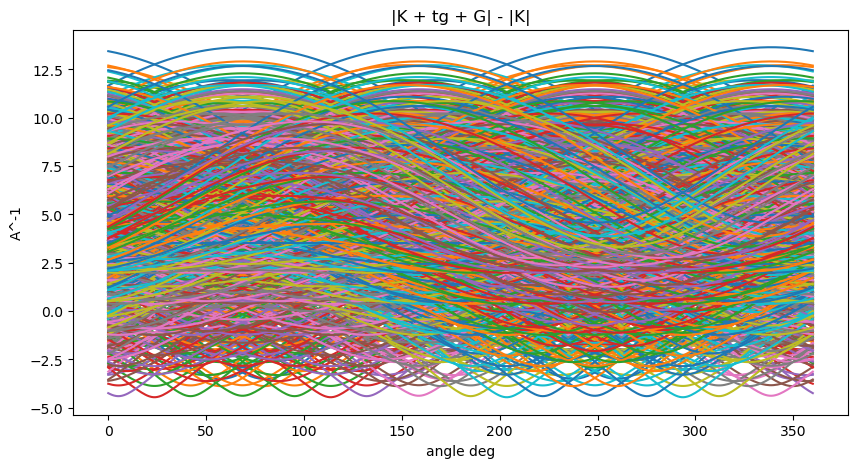

In [6]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            ax.plot(np.arange(361), kout_len_diff[xIdx, yIdx, zIdx] / 1e4,
                    label="G=({}, {}, {})".format(xIdx, yIdx, zIdx))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
#plt.legend()
plt.show()

In [7]:
for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            x = np.argmin(np.abs(kout_len_diff[xIdx, yIdx, zIdx] / 1e4))
            k_tmp = kout[xIdx, yIdx, zIdx, x]
            
            if x == 360:
                continue
                            
            if kout_len_diff[xIdx, yIdx, zIdx, x - 1] *  kout_len_diff[xIdx, yIdx, zIdx, x + 1] < 0:
                
                if k_tmp[0] > 0 and k_tmp[1] > 0 and k_tmp[2] > 0:
                    # Normalize the wave-vector
                        direction = k_tmp / np.linalg.norm(k_tmp)
                
                        # Get the position
                        position = direction / direction[2] * 11.5

                        # Impose the det position limitation
                        if position[0] < 20 and position[1]<20:
                            #if xIdx - 5 >= 0 and yIdx - 5>= 0 and zIdx - 5>= 0 :
                        
                            print("G=({}, {}, {})".format(xIdx - 5, yIdx - 5, zIdx - 5), kout[xIdx, yIdx, zIdx, x], x  + 1 - 360)
                            print("detector positoin with respect to the sample in cm", position)
                            print(bLattice[xIdx, yIdx, zIdx, 0])
                            print('------------------------------')

G=(1, -3, -2) [11399.39870066 37284.77404004 30327.17273813] -225
detector positoin with respect to the sample in cm [ 4.32262797 14.13830775 11.5       ]
[  9351.38835777 -48270.30965823 -34742.02993261]
------------------------------
G=(1, -3, -1) [12705.4932527  31152.62509649 36746.83255881] -204
detector positoin with respect to the sample in cm [ 3.97621134  9.74928079 11.5       ]
[ 12559.23900119 -48270.30965823 -18974.94028801]
------------------------------
G=(1, -3, 0) [13026.5342071  28691.52267352 38324.7992631 ] -184
detector positoin with respect to the sample in cm [ 3.90883048  8.60937349 11.5       ]
[ 15767.0896446  -48270.30965823  -3207.85064341]
------------------------------
G=(1, -3, 1) [12728.37956658 31165.7042614  36859.32238536] -167
detector positoin with respect to the sample in cm [ 3.97121693  9.72360792 11.5       ]
[ 18974.94028801 -48270.30965823  12559.23900119]
------------------------------
G=(1, -2, -2) [13390.42890261 26052.21106171 40113.3988343